In [2]:
import psycopg2
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#aesthetic style for my visualizations

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'axes.titlesize': 14, 'axes.labelsize': 12})

In [5]:
#Connection to my POstgres Database

DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "northpeak_db"
DB_USER = "postgres"
DB_PASS = "marcelle12345"

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

query = """
SELECT 
    f.discount_pct,
    f.quantity_sold,
    f.unit_cost,
    f.unit_price,
    f.net_revenue,
    f.net_profit,
    f.margin_pct,
    d.year,
    d.quarter,
    p.category
FROM "Fact_Sales" f
JOIN "Dim_Date" d ON f.date_key = d.date_key
JOIN "Dim_Product" p ON f.product_id = p.product_id;
"""

print("Marcelle, fetch the dataset from PostgreSQL...")
df = pd.read_sql(query, engine)
print(f"Marcelle your Data loaded successfully! Total records: {len(df):,}")

Marcelle, fetch the dataset from PostgreSQL...
Marcelle your Data loaded successfully! Total records: 70,000


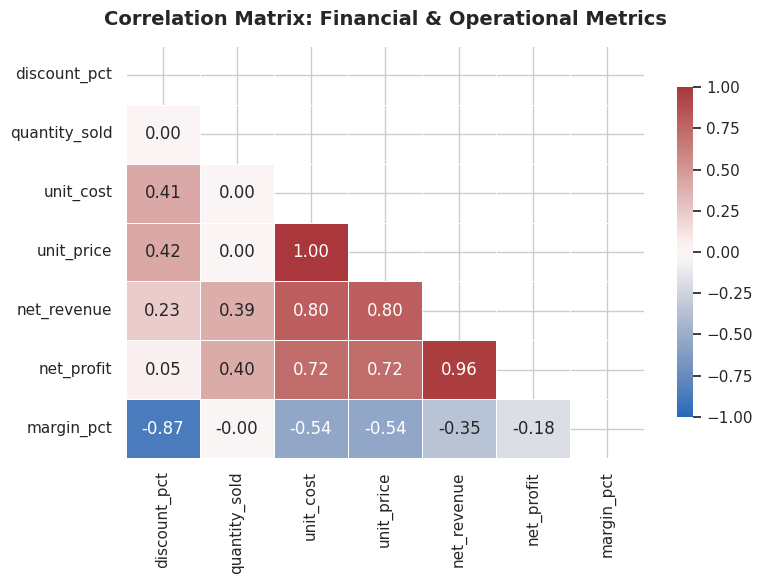

In [6]:
#VISUALIZATION 1: CORRELATION HEATMAP

plt.figure(figsize=(8, 6))

corr_cols = ['discount_pct', 'quantity_sold', 'unit_cost', 'unit_price', 'net_revenue', 'net_profit', 'margin_pct']
corr_matrix = df[corr_cols].corr()

# Generate mask for upper triangle to clean up visual clutter
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap="vlag", 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title("Correlation Matrix: Financial & Operational Metrics", pad=15, fontweight='bold')
plt.tight_layout()
plt.show()


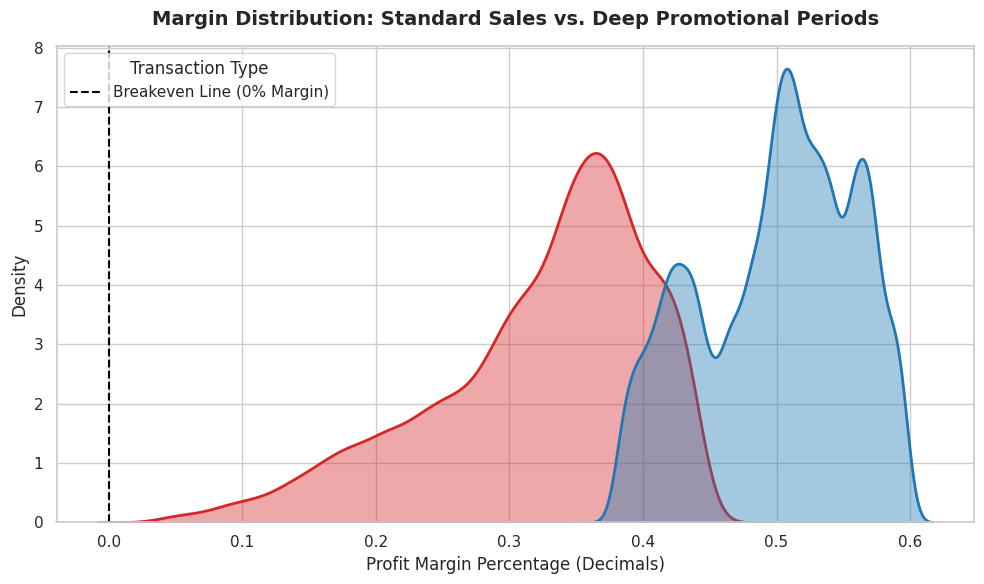

In [ ]:
#VISUALIZATION 2: MARGIN DISTRIBUTION (BEFORE VS. AFTER DEEP PROMOTIONS)

plt.figure(figsize=(10, 6))

# Classify transactions into standard baseline (< 15% discount) vs. deep promo (>= 15% discount)
df['promo_period'] = np.where(df['discount_pct'] >= 0.15, 'Deep Promotional (>= 15% Discount)', 'Standard Baseline (< 15% Discount)')

sns.kdeplot(
    data=df, 
    x='margin_pct', 
    hue='promo_period', 
    common_norm=False, 
    fill=True, 
    alpha=0.4, 
    linewidth=2,
    palette=['#1f77b4', '#d62728']
)

# Reference line for 0% Profit Margin (Breakeven)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Breakeven Line (0% Margin)')

plt.title("Margin Distribution: Standard Sales vs. Deep Promotional Periods", pad=15, fontweight='bold')
plt.xlabel("Profit Margin Percentage (Decimals)")
plt.ylabel("Density")
plt.legend(title="Transaction Type", loc="upper left")
plt.tight_layout()
plt.show()

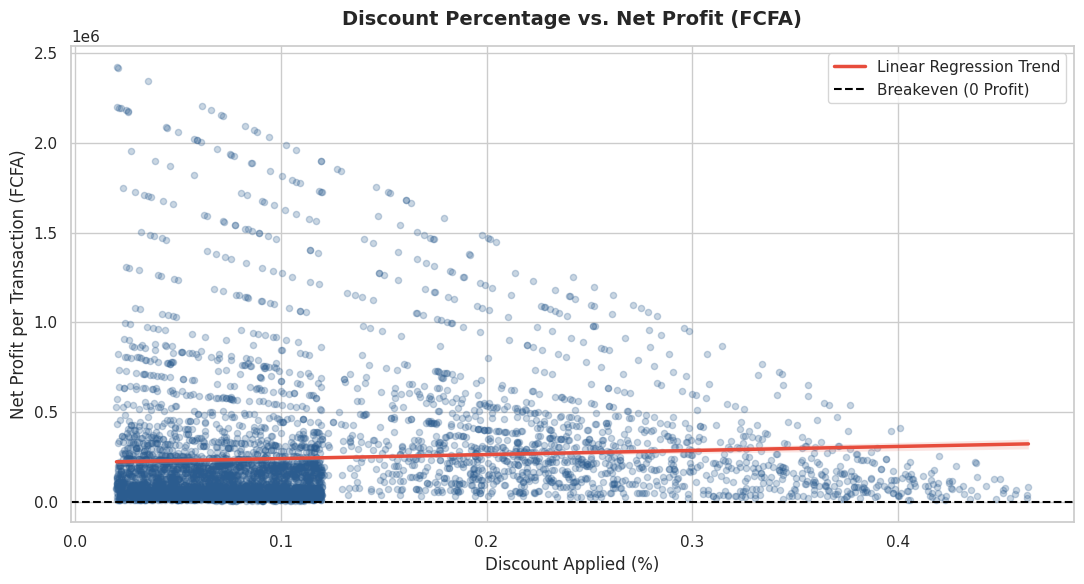

In [ ]:
#VISUALIZATION 3: SCATTER PLOT & BREAKEVEN DISCOUNT THRESHOLD
plt.figure(figsize=(11, 6))

# Downsample points for scatter plot rendering speed while retaining exact trendline
sample_df = df.sample(n=5000, random_state=42) if len(df) > 5000 else df

sns.regplot(
    data=sample_df,
    x='discount_pct',
    y='net_profit',
    scatter_kws={'alpha': 0.25, 'color': '#2b5c8f', 's': 20},
    line_kws={'color': '#e74c3c', 'linewidth': 2.5, 'label': 'Linear Regression Trend'}
)

# Breakeven line (Net Profit = 0 FCFA)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, label='Breakeven (0 Profit)')

plt.title("Discount Percentage vs. Net Profit (FCFA)", pad=15, fontweight='bold')
plt.xlabel("Discount Applied (%)")
plt.ylabel("Net Profit per Transaction (FCFA)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


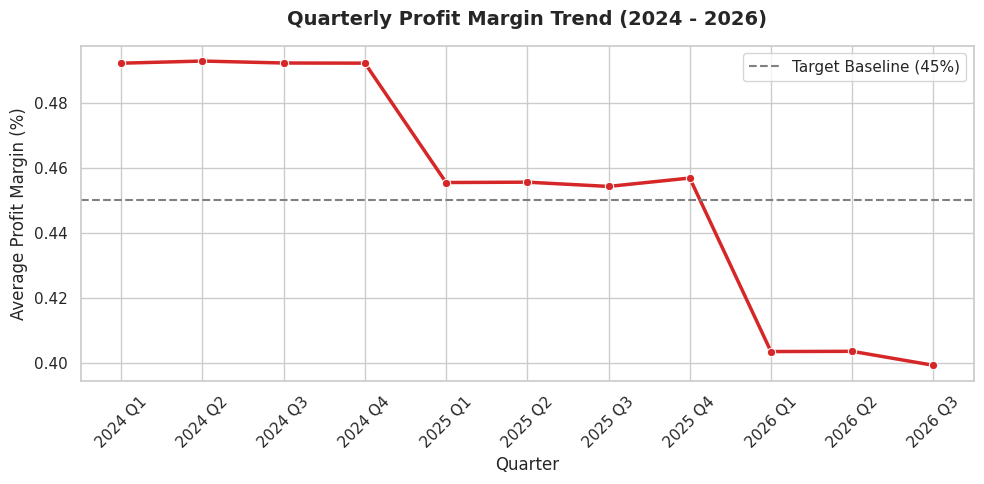

In [ ]:
#CHART 4: QUARTERLY MARGIN TREND OVER TIME

df['period'] = df['year'].astype(str) + " Q" + df['quarter'].astype(str)
quarterly_trend = df.groupby('period')['margin_pct'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=quarterly_trend, x='period', y='margin_pct', marker='o', color='#d62728', linewidth=2.5)
plt.axhline(y=0.45, color='gray', linestyle='--', label='Target Baseline (45%)')
plt.title("Quarterly Profit Margin Trend (2024 - 2026)", pad=15, fontweight='bold')
plt.xlabel("Quarter")
plt.ylabel("Average Profit Margin (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\Tandah\AppData\Local\Temp\ipykernel_9384\4264952833.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_margin, x='margin_pct', y='category', palette='Blues_r')


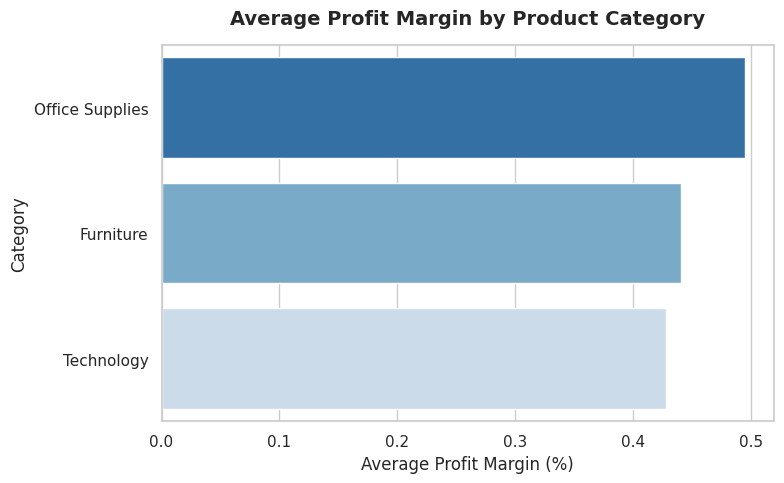

In [8]:
# CHART 5: MARGIN COMPARISON ACROSS PRODUCT CATEGORIES
category_margin = df.groupby('category')['margin_pct'].mean().reset_index().sort_values(by='margin_pct', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=category_margin, x='margin_pct', y='category', palette='Blues_r')
plt.title("Average Profit Margin by Product Category", pad=15, fontweight='bold')
plt.xlabel("Average Profit Margin (%)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

C:\Users\Tandah\AppData\Local\Temp\ipykernel_9384\3859427342.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='quantity_sold', y='discount_pct', palette='crest')


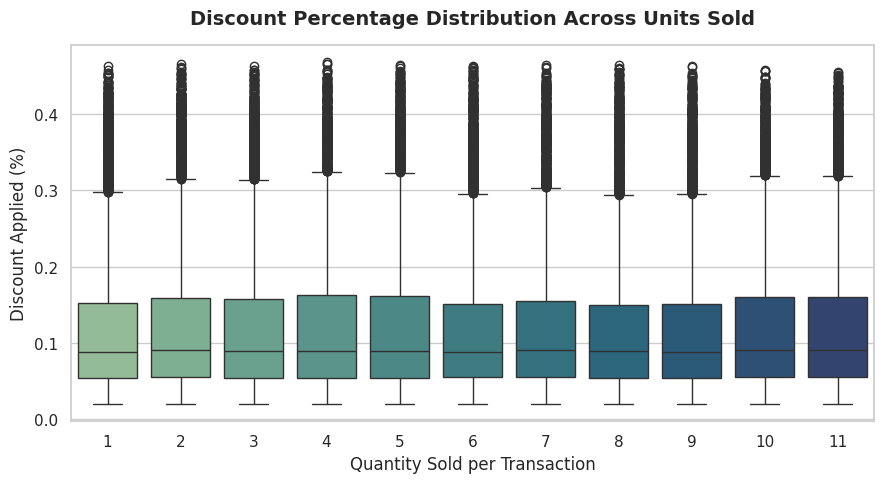

In [9]:
# CHART 6: DISCOUNT VS. QUANTITY SOLD (VOLUME ELASTICITY)
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='quantity_sold', y='discount_pct', palette='crest')
plt.title("Discount Percentage Distribution Across Units Sold", pad=15, fontweight='bold')
plt.xlabel("Quantity Sold per Transaction")
plt.ylabel("Discount Applied (%)")
plt.tight_layout()
plt.show()

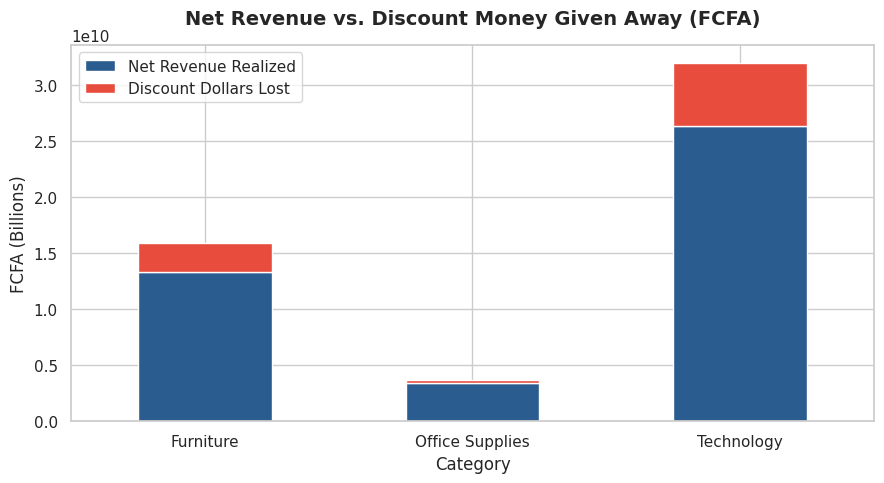

In [11]:
# CHART 7: GROSS VS. NET REVENUE LOSS ACROSS CATEGORIES
df['discount_amount'] = (df['unit_price'] * df['quantity_sold']) - df['net_revenue']
cat_revenue = df.groupby('category')[['net_revenue', 'discount_amount']].sum().reset_index()

cat_revenue.plot(x='category', kind='bar', stacked=True, figsize=(9, 5), color=['#2b5c8f', '#e74c3c'])
plt.title("Net Revenue vs. Discount Money Given Away (FCFA)", pad=15, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("FCFA (Billions)")
plt.xticks(rotation=0)
plt.legend(['Net Revenue Realized', 'Discount Dollars Lost'])
plt.tight_layout()
plt.show()